<a href="https://colab.research.google.com/github/fatahrahimi330/XST-Deepfake-Detection/blob/master/new_version/6_new_version.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Full Proper Video Model Pipeline

## 1. Imports

In [ ]:
import os
import random
import zipfile
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from tqdm.auto import tqdm
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm

## 2. Set seed

In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

## 3. Mount drive and unzip dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# zip_path = "/content/drive/MyDrive/processed_ffpp.zip"
# extract_path = "/content/processed_ffpp"

# os.makedirs(extract_path, exist_ok=True)

# with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#     zip_ref.extractall(extract_path)

# print("Extraction complete!")
# print(os.listdir(extract_path))

Mounted at /content/drive


## 4. Set dataset root

In [ ]:
data_root = "/content/drive/MyDrive/XST-Deepfake-Detection/processed_ffpp"
print(os.listdir(data_root))

['.DS_Store', 'val', 'train', 'test']


## 5. Transforms

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

## 6. Video sequence dataset

In [ ]:
class VideoFrameDataset(Dataset):
    """
    One sample = one video folder containing multiple frame images.
    Returns:
        frames_tensor: shape (T, C, H, W)
        label: 0 for fake, 1 for real
    """

    IMG_EXTS = (".jpg", ".jpeg", ".png")

    def __init__(self, root_dir, transform=None, num_frames=8, mode="uniform"):
        self.root_dir = root_dir
        self.transform = transform
        self.num_frames = num_frames
        self.mode = mode  # "uniform" or "random"

        self.classes = ["fake", "real"]
        self.class_to_idx = {"fake": 0, "real": 1}
        self.samples = []

        for class_name in self.classes:
            class_dir = os.path.join(root_dir, class_name)
            if not os.path.isdir(class_dir):
                continue

            for video_name in sorted(os.listdir(class_dir)):
                video_dir = os.path.join(class_dir, video_name)
                if not os.path.isdir(video_dir):
                    continue

                frame_files = sorted([
                    os.path.join(video_dir, f)
                    for f in os.listdir(video_dir)
                    if f.lower().endswith(self.IMG_EXTS)
                ])

                if len(frame_files) == 0:
                    continue

                self.samples.append((frame_files, self.class_to_idx[class_name], video_dir))

        print(f"[{root_dir}] Found {len(self.samples)} videos.")

    def __len__(self):
        return len(self.samples)

    def _sample_indices(self, n_frames):
        if n_frames >= self.num_frames:
            if self.mode == "random":
                indices = sorted(random.sample(range(n_frames), self.num_frames))
            else:
                indices = np.linspace(0, n_frames - 1, self.num_frames, dtype=int).tolist()
        else:
            # Repeat frames if video has fewer than num_frames
            indices = np.linspace(0, n_frames - 1, self.num_frames, dtype=int).tolist()

        return indices

    def __getitem__(self, idx):
        frame_files, label, video_dir = self.samples[idx]
        indices = self._sample_indices(len(frame_files))

        frames = []
        for i in indices:
            img_path = frame_files[i]
            img = Image.open(img_path).convert("RGB")

            if self.transform is not None:
                img = self.transform(img)

            frames.append(img)

        frames = torch.stack(frames, dim=0)  # (T, C, H, W)
        return frames, torch.tensor(label, dtype=torch.float32)

## 7. Create datasets and loaders

In [ ]:
NUM_FRAMES = 8
BATCH_SIZE = 4  # lower than frame model because sequence model uses more memory

train_dataset = VideoFrameDataset(
    root_dir=os.path.join(data_root, "train"),
    transform=train_transform,
    num_frames=NUM_FRAMES,
    mode="random" # uniform
)

val_dataset = VideoFrameDataset(
    root_dir=os.path.join(data_root, "val"),
    transform=val_test_transform,
    num_frames=NUM_FRAMES,
    mode="uniform"
)

test_dataset = VideoFrameDataset(
    root_dir=os.path.join(data_root, "test"),
    transform=val_test_transform,
    num_frames=NUM_FRAMES,
    mode="uniform"
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

[/content/drive/MyDrive/XST-Deepfake-Detection/processed_ffpp/train] Found 280 videos.
[/content/drive/MyDrive/XST-Deepfake-Detection/processed_ffpp/val] Found 60 videos.
[/content/drive/MyDrive/XST-Deepfake-Detection/processed_ffpp/test] Found 60 videos.


## 8. Check shapes

In [ ]:
videos, labels = next(iter(train_loader))
print("Video batch shape:", videos.shape)   # (B, T, C, H, W)
print("Labels shape:", labels.shape)

Video batch shape: torch.Size([4, 8, 3, 224, 224])
Labels shape: torch.Size([4])


## 9. Improved CNN + ViT + BiLSTM model

In [ ]:
class CNN_ViT_BiLSTM(nn.Module):
    def __init__(
        self,
        cnn_model='efficientnet_b0',
        vit_model='vit_base_patch16_224',
        proj_dim=128,
        lstm_hidden=128,
        lstm_layers=1,
        dropout=0.3,
        freeze_cnn=True,
        freeze_vit=True
    ):
        super().__init__()

        # CNN backbone
        self.cnn = timm.create_model(cnn_model, pretrained=True)
        self.cnn.reset_classifier(0)
        cnn_feature_dim = self.cnn.num_features

        # ViT backbone
        self.vit = timm.create_model(vit_model, pretrained=True)
        self.vit.reset_classifier(0)
        vit_feature_dim = self.vit.num_features

        if freeze_cnn:
            for p in self.cnn.parameters():
                p.requires_grad = False

        if freeze_vit:
            for p in self.vit.parameters():
                p.requires_grad = False

        # Projection layers
        self.cnn_proj = nn.Sequential(
            nn.Linear(cnn_feature_dim, proj_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.vit_proj = nn.Sequential(
            nn.Linear(vit_feature_dim, proj_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.fusion_norm = nn.LayerNorm(proj_dim * 2)

        # Temporal modeling
        self.lstm = nn.LSTM(
            input_size=proj_dim * 2,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,
            dropout=0.0 if lstm_layers == 1 else dropout
        )

        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(lstm_hidden * 2, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        # x: (B, T, C, H, W)
        B, T, C, H, W = x.shape
        x = x.view(B * T, C, H, W)

        # CNN features
        cnn_raw = self.cnn.forward_features(x)
        cnn_feat = self.cnn.global_pool(cnn_raw).flatten(1)

        # ViT features
        vit_raw = self.vit.forward_features(x)
        vit_feat = vit_raw[:, 0]  # CLS token

        # Projection
        cnn_feat = self.cnn_proj(cnn_feat)
        vit_feat = self.vit_proj(vit_feat)

        # Fusion
        fused = torch.cat([cnn_feat, vit_feat], dim=1)
        fused = self.fusion_norm(fused)

        # Sequence reshape
        seq_feat = fused.view(B, T, -1)

        # BiLSTM
        lstm_out, _ = self.lstm(seq_feat)

        # Temporal mean pooling
        temporal_feat = lstm_out.mean(dim=1)

        # Classification
        out = self.classifier(temporal_feat)
        return out

## 10. Device, loss, optimizer

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN_ViT_BiLSTM().to(device)

criterion = nn.BCEWithLogitsLoss()

trainable_params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(trainable_params, lr=1e-4, weight_decay=1e-4)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

In [ ]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=2
)

## 11. Training and validation functions

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    all_labels = []
    all_preds = []

    for videos, labels in tqdm(loader, desc="Training"):
        videos = videos.to(device)
        labels = labels.unsqueeze(1).to(device)

        optimizer.zero_grad()
        outputs = model(videos)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        all_labels.extend(labels.cpu().numpy().ravel())
        all_preds.extend(preds.cpu().numpy().ravel())

    epoch_loss = running_loss / len(loader)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds)

    return epoch_loss, epoch_acc, epoch_f1


def validate_one_epoch(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for videos, labels in tqdm(loader, desc="Validation"):
            videos = videos.to(device)
            labels = labels.unsqueeze(1).to(device)

            outputs = model(videos)
            loss = criterion(outputs, labels)

            running_loss += loss.item()

            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()

            all_labels.extend(labels.cpu().numpy().ravel())
            all_preds.extend(preds.cpu().numpy().ravel())
            all_probs.extend(probs.cpu().numpy().ravel())

    epoch_loss = running_loss / len(loader)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds)
    epoch_auc = roc_auc_score(all_labels, all_probs)

    return epoch_loss, epoch_acc, epoch_f1, epoch_auc

## 12. Full training loop with checkpoint and early stopping

In [ ]:
checkpoint_path = "/content/drive/MyDrive/XST-Deepfake-Detection/new_version/video_checkpoint.pth"
best_model_path = "/content/drive/MyDrive/XST-Deepfake-Detection/new_version/video_best_model.pth"
model_path = "/content/drive/MyDrive/XST-Deepfake-Detection/new_version/video_model.pth"

epochs = 20
patience = 5
counter = 0
best_val_f1 = 0.0
start_epoch = 0

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []
train_f1s, val_f1s = [], []
val_aucs = []

if os.path.exists(checkpoint_path):
    print("Loading checkpoint...")
    checkpoint = torch.load(checkpoint_path, map_location=device)

    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    start_epoch = checkpoint["epoch"] + 1
    best_val_f1 = checkpoint.get("best_val_f1", 0.0)
    counter = checkpoint.get("counter", 0)

    train_losses = checkpoint.get("train_losses", [])
    val_losses = checkpoint.get("val_losses", [])
    train_accuracies = checkpoint.get("train_accuracies", [])
    val_accuracies = checkpoint.get("val_accuracies", [])
    train_f1s = checkpoint.get("train_f1s", [])
    val_f1s = checkpoint.get("val_f1s", [])
    val_aucs = checkpoint.get("val_aucs", [])

    print(f"Resuming from epoch {start_epoch}")

for epoch in range(start_epoch, epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")

    if epoch == 8:
      print("🔓 Unfreezing CNN + ViT (correct version)...")

      # Unfreeze full backbones (safe + standard)
      for param in model.cnn.parameters():
          param.requires_grad = True

      for param in model.vit.parameters():
          param.requires_grad = True

      # IMPORTANT: rebuild optimizer properly
      optimizer = torch.optim.AdamW([
          {"params": model.classifier.parameters(), "lr": 1e-4},
          {"params": model.lstm.parameters(), "lr": 1e-4},
          {"params": model.cnn.parameters(), "lr": 1e-5},
          {"params": model.vit.parameters(), "lr": 1e-5},
      ], weight_decay=1e-3)

    train_loss, train_acc, train_f1 = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    val_loss, val_acc, val_f1, val_auc = validate_one_epoch(
        model, val_loader, criterion, device
    )

    scheduler.step(val_f1)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    train_f1s.append(train_f1)
    val_f1s.append(val_f1)
    val_aucs.append(val_auc)

    print(
        f"Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, Train F1={train_f1:.4f} | "
        f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}, Val F1={val_f1:.4f}, Val AUC={val_auc:.4f}"
    )

    if val_f1 > best_val_f1:
        print("✅ Validation F1 improved — saving best model")
        best_val_f1 = val_f1
        counter = 0
        torch.save(model.state_dict(), best_model_path)
    else:
        counter += 1
        print(f"⚠️ No improvement ({counter}/{patience})")


    torch.save(model.state_dict(), model_path)
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "best_val_f1": best_val_f1,
        "counter": counter,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accuracies": train_accuracies,
        "val_accuracies": val_accuracies,
        "train_f1s": train_f1s,
        "val_f1s": val_f1s,
        "val_aucs": val_aucs
    }, checkpoint_path)

    if counter >= patience:
        print("⛔ Early stopping triggered")
        break


Epoch 1/20


Training:   0%|          | 0/70 [00:00<?, ?it/s]

Validation:   0%|          | 0/15 [00:00<?, ?it/s]

Train Loss=0.6893, Train Acc=0.5000, Train F1=0.6667 | Val Loss=0.6673, Val Acc=0.5000, Val F1=0.6667, Val AUC=0.7778
✅ Validation F1 improved — saving best model

Epoch 2/20


Training:   0%|          | 0/70 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/15 [00:00<?, ?it/s]

Train Loss=0.1042, Train Acc=0.9607, Train F1=0.9603 | Val Loss=0.1988, Val Acc=0.9667, Val F1=0.9655, Val AUC=0.9778
✅ Validation F1 improved — saving best model

Epoch 20/20


Training:   0%|          | 0/70 [00:00<?, ?it/s]

Validation:   0%|          | 0/15 [00:00<?, ?it/s]

Train Loss=0.0913, Train Acc=0.9500, Train F1=0.9510 | Val Loss=0.1922, Val Acc=0.9000, Val F1=0.9032, Val AUC=0.9778
⚠️ No improvement (1/5)


## 13. Plot curves

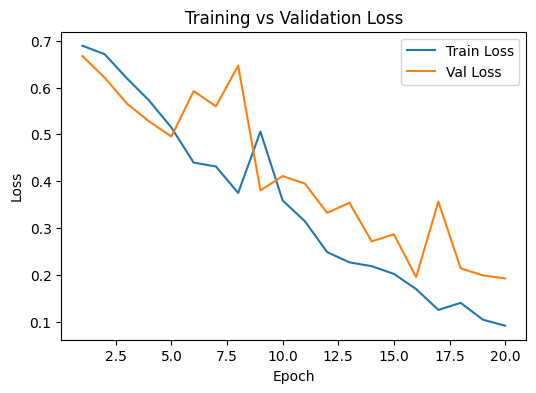

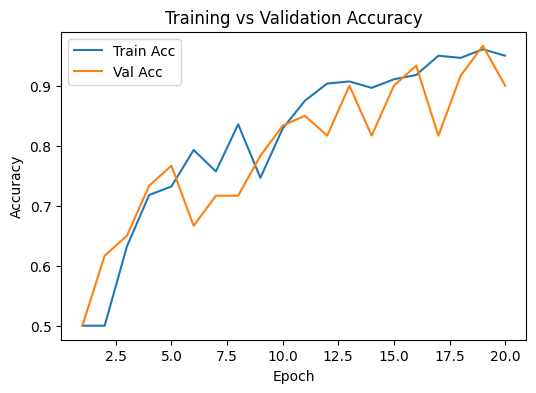

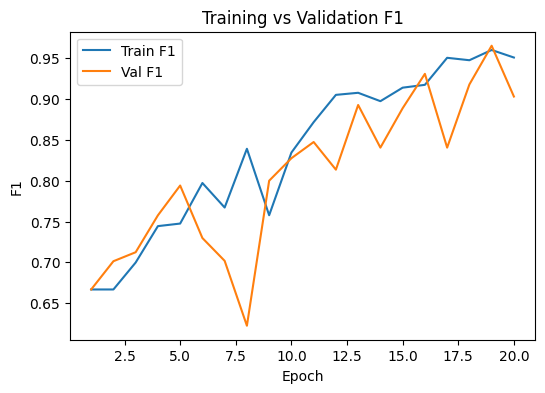

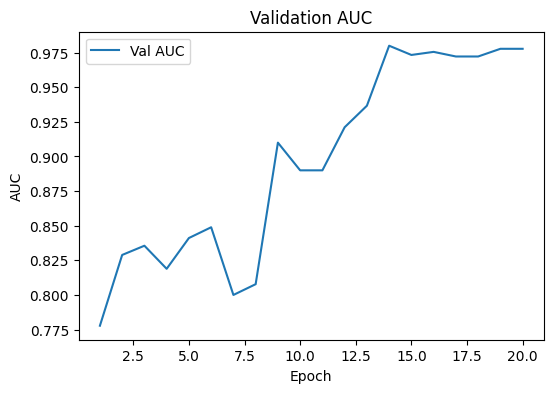

In [ ]:
epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs_range, train_losses, label="Train Loss")
plt.plot(epochs_range, val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(epochs_range, train_accuracies, label="Train Acc")
plt.plot(epochs_range, val_accuracies, label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(epochs_range, train_f1s, label="Train F1")
plt.plot(epochs_range, val_f1s, label="Val F1")
plt.xlabel("Epoch")
plt.ylabel("F1")
plt.title("Training vs Validation F1")
plt.legend()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(epochs_range, val_aucs, label="Val AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.title("Validation AUC")
plt.legend()
plt.show()

## 14. Test evaluation

In [ ]:
best_model_path = "/content/drive/MyDrive/XST-Deepfake-Detection/new_version/video_best_model.pth"
checkpoint_path = "/content/drive/MyDrive/XST-Deepfake-Detection/new_version/video_checkpoint.pth"

In [ ]:
model.load_state_dict(torch.load(best_model_path, map_location=device))

<All keys matched successfully>

In [ ]:
def test_model(model, loader, device):
    model.eval()

    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for videos, labels in tqdm(loader, desc="Testing"):
            videos = videos.to(device)
            labels = labels.unsqueeze(1).to(device)

            outputs = model(videos)
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()

            all_labels.extend(labels.cpu().numpy().ravel())
            all_preds.extend(preds.cpu().numpy().ravel())
            all_probs.extend(probs.cpu().numpy().ravel())

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    auc = roc_auc_score(all_labels, all_probs)

    print(f"Test Accuracy: {acc:.4f}")
    print(f"Test F1-score: {f1:.4f}")
    print(f"Test AUC: {auc:.4f}")

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

In [ ]:
all_labels, all_preds, all_probs = test_model(model, test_loader, device)

Testing:   0%|          | 0/15 [00:00<?, ?it/s]

Test Accuracy: 0.9000
Test F1-score: 0.8966
Test AUC: 0.9544


In [ ]:
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

print(f"Loaded checkpoint from epoch {checkpoint['epoch'] + 1}")

all_labels, all_preds, all_probs = test_model(model, test_loader, device)

In [ ]:
import numpy as np
from sklearn.metrics import f1_score, accuracy_score

thresholds = np.linspace(0.0, 1.0, 101)

best_threshold = 0.5
best_f1 = 0.0

for t in thresholds:
    preds = (all_probs > t).astype(int)
    f1 = f1_score(all_labels, preds)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print(f"\n✅ Best Threshold: {best_threshold:.2f}")
print(f"✅ Best F1-score: {best_f1:.4f}")


✅ Best Threshold: 0.34
✅ Best F1-score: 0.8966


In [ ]:
best_preds = (all_probs > best_threshold).astype(int)

print("\n📊 Test performance with best threshold:")
print("Accuracy:", accuracy_score(all_labels, best_preds))
print("F1-score:", f1_score(all_labels, best_preds))


📊 Test performance with best threshold:
Accuracy: 0.9
F1-score: 0.896551724137931


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, best_preds)
print("\nConfusion Matrix:\n", cm)


Confusion Matrix:
 [[28  2]
 [ 4 26]]


## 15. Classification report and confusion matrix

              precision    recall  f1-score   support

        fake       0.88      0.93      0.90        30
        real       0.93      0.87      0.90        30

    accuracy                           0.90        60
   macro avg       0.90      0.90      0.90        60
weighted avg       0.90      0.90      0.90        60

Confusion Matrix:
 [[28  2]
 [ 4 26]]


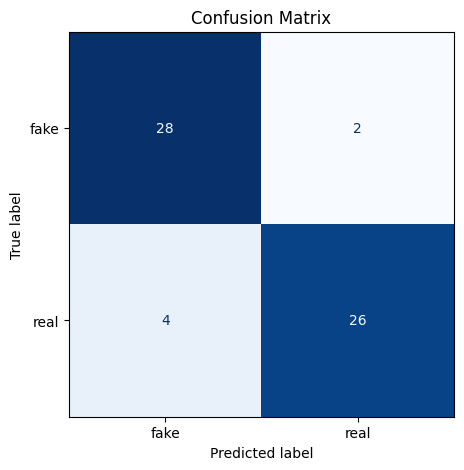

In [ ]:
target_names = ["fake", "real"]

print(classification_report(
    all_labels.astype(int),
    all_preds.astype(int),
    target_names=target_names
))

cm = confusion_matrix(all_labels.astype(int), all_preds.astype(int))
print("Confusion Matrix:\n", cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(cmap="Blues", colorbar=False, ax=ax)
plt.title("Confusion Matrix")
plt.show()

## 16. Predict one video folder

In [ ]:
def predict_video_folder(model, video_dir, transform, device, num_frames=8):
    model.eval()

    frame_files = sorted([
        os.path.join(video_dir, f)
        for f in os.listdir(video_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

    if len(frame_files) == 0:
        raise ValueError(f"No frames found in {video_dir}")

    indices = np.linspace(0, len(frame_files) - 1, num_frames, dtype=int).tolist()

    frames = []
    for i in indices:
        img = Image.open(frame_files[i]).convert("RGB")
        img = transform(img)
        frames.append(img)

    frames = torch.stack(frames, dim=0).unsqueeze(0).to(device)  # (1, T, C, H, W)

    with torch.no_grad():
        output = model(frames)
        prob = torch.sigmoid(output).item()
        pred = 1 if prob > 0.5 else 0

    classes = ["fake", "real"]

    if prob > 0.5:
      return classes[pred], prob
    else:
      prob = 1-prob
      return classes[pred], prob

In [ ]:
sample_video_dir = os.path.join(data_root, "test", "real", "03__talking_against_wall")
pred_label, prob = predict_video_folder(
    model, sample_video_dir, val_test_transform, device, num_frames=64
)
print(f"Prediction: {pred_label} ({prob:.4f})")

Prediction: real (0.9961)


## 17. FGSM Attack Function

In [ ]:
# -----------------------------
# Load best model
# -----------------------------
print("🔄 Loading best model weights …")
checkpoint = torch.load(checkpoint_path, map_location=device,weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)

🔄 Loading best model weights …


CNN_ViT_BiLSTM(
  (cnn): EfficientNet(
    (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNormAct2d(
      32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
    (blocks): Sequential(
      (0): Sequential(
        (0): DepthwiseSeparableConv(
          (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (bn1): BatchNormAct2d(
            32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): SiLU(inplace=True)
          )
          (aa): Identity()
          (se): SqueezeExcite(
            (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (act1): SiLU(inplace=True)
            (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (gate): Sigmoid()
          )
          (conv_pw): Con

In [ ]:
def fgsm_attack_video(images, epsilon, data_grad, mean, std):
    """
    images: (B, T, C, H, W) normalized
    data_grad: same shape
    """

    # FGSM step
    perturbed = images + epsilon * data_grad.sign()

    # Clamp in NORMALIZED space
    min_val = (0 - mean) / std
    max_val = (1 - mean) / std

    perturbed = torch.max(torch.min(perturbed, max_val), min_val)

    return perturbed

In [ ]:
mean = torch.tensor([0.485, 0.456, 0.406], device=device).view(1,1,3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225], device=device).view(1,1,3,1,1)

In [ ]:
model.eval()
epsilon = 0.1  # start stronger than 0.03

all_probs, all_preds, all_labels = [], [], []
test_loss = 0.0

for images, labels in tqdm(test_loader, desc="FGSM Testing"):

    images = images.to(device)                         # (B, T, C, H, W)
    labels = labels.view(-1, 1).to(device)             # (B, 1)

    # Enable gradient on input
    images.requires_grad = True

    # Forward
    outputs = model(images)
    loss = criterion(outputs, labels)

    # Backward
    model.zero_grad()
    loss.backward()

    # Get gradient
    data_grad = images.grad.detach()

    # Generate adversarial video
    adv_images = fgsm_attack_video(images, epsilon, data_grad, mean, std)

    # Inference (no grad)
    with torch.no_grad():
        adv_outputs = model(adv_images)

        loss = criterion(adv_outputs, labels)
        test_loss += loss.item()

        probs = torch.sigmoid(adv_outputs).cpu().numpy().ravel()
        preds = (probs >= 0.5).astype(int)

    all_probs.extend(probs)
    all_preds.extend(preds)
    all_labels.extend(labels.cpu().numpy().ravel())

FGSM Testing:   0%|          | 0/15 [00:00<?, ?it/s]

In [ ]:
# -----------------------------
# Metrics
# -----------------------------
test_loss /= len(test_loader)

test_acc = accuracy_score(all_labels, all_preds)
test_auc = roc_auc_score(all_labels, all_probs)
test_f1  = f1_score(all_labels, all_preds)

print("\n" + "="*60)
print("  FGSM ADVERSARIAL TEST RESULTS")
print("="*60)
print(f"  Epsilon:  {epsilon}")
print(f"  Loss:     {test_loss:.4f}")
print(f"  Accuracy: {test_acc*100:.2f}%")
print(f"  AUC-ROC:  {test_auc:.4f}")
print(f"  F1 Score: {test_f1:.4f}")
print("="*60)


# -----------------------------
# Target check
# -----------------------------
if test_acc >= 0.95:
    print(f"  ✅ TARGET ACHIEVED: {test_acc*100:.2f}% ≥ 95%")
else:
    print(f"  ⚠️ Robustness Drop. Gap: {(0.95 - test_acc)*100:.2f}%")


  FGSM ADVERSARIAL TEST RESULTS
  Epsilon:  0.1
  Loss:     1.9530
  Accuracy: 41.67%
  AUC-ROC:  0.4244
  F1 Score: 0.5205
  ⚠️ Robustness Drop. Gap: 53.33%


## 18. For saving Notebook

In [ ]:
import nbformat

notebook_path = "/content/drive/MyDrive/XST-Deepfake-Detection/new_version/new_version.ipynb"

nb = nbformat.read(notebook_path, as_version=4)

# Remove only widget metadata
if "widgets" in nb.metadata:
    del nb.metadata["widgets"]

nbformat.write(nb, notebook_path)

print("Fixed notebook (outputs preserved ✅)")